In [68]:
import cygnet, torch, time
from matplotlib import pyplot as plt
import numpy as np
from torchvision.ops import sigmoid_focal_loss

f_path = "/home/frx/midas/run111005.mid.gz"

skips = 0
c = 0

f = cygnet.open_mid(f_path)
for event in f:
	break
	if event.header.is_midas_internal_event() or event.header.event_id != 1:
		continue
	if skips > 0:
		skips -= 1
		continue
	print(f"event {event.header.serial_number}")
	for bank_name, bank in event.banks.items():
		print(bank_name)
	break


In [69]:
def daq_cam2array(bank):
	shapex=4096
	shapey=2304

	image = np.reshape(bank.data, (shapey, shapex))
	return image

class MidasWrapper():
	def __init__(self, f_path, skip_count=False):
		self.ff = cygnet.open_mid(f_path)
		self.skip_count = skip_count
		self.count = self.get_cam_events_count()

		print(f"the midas file contains {self.count} cam events")

	def get_cam_events_count(self):
		if self.skip_count:
			return 10000
		c = 0
		for event in self.ff:
			if event.header.is_midas_internal_event() or event.header.event_id != 1:
				continue
			c += 1

		return c

	def get_event_cam(self, num):
		self.ff.jump_to_start()
		if num >= self.count:
			print(f"{num} OOB")
		for event in self.ff:
			if event.header.is_midas_internal_event() or event.header.event_id != 1:
				continue
			if num > 0:
				num -= 1
				continue
			print(f"event {event.header.serial_number}")
			for bank_name, bank in event.banks.items():
				print(bank_name)
				if bank_name=='CAM0': # CAM image
					image = daq_cam2array(bank)
					return image
			break


mmm = MidasWrapper(f_path, True)


the midas file contains 10000 cam events


event 4
DIG0
DGH0
CAM0


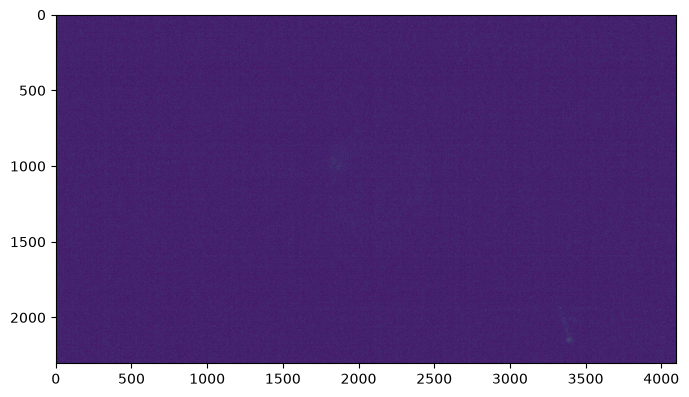

In [70]:
pic_num = 4
# 2

img = mmm.get_event_cam(pic_num)

plt.figure(figsize=(8,8))
plt.imshow(img, vmin=cygnet.picmin, vmax=cygnet.picmax)
plt.show()

===== test transforms =====


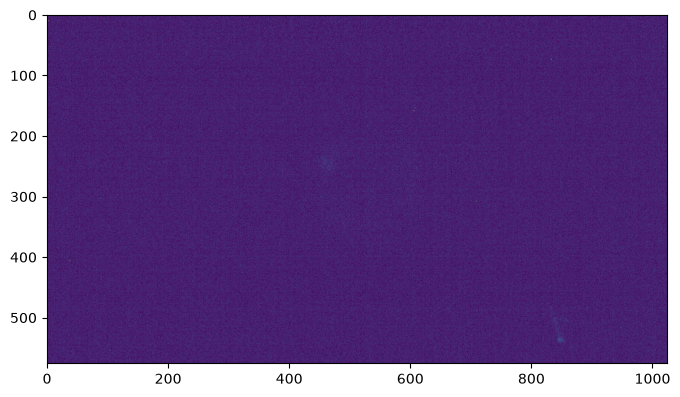

In [71]:
print("===== test transforms =====")

in_t = cygnet.input_transform_builder(4)
d_img = in_t(img).squeeze()

plt.figure(figsize=(8,8))
plt.imshow(d_img, vmin=cygnet.picmin, vmax=cygnet.picmax)
plt.show()

in_img = cygnet.itrtr(d_img)

In [72]:
import os

net_folder = "/home/frx/cygnet/saved_models"
for el in os.listdir(net_folder):
	print(el)

best_model_base16_res_drop.pt
2026_Jul_23__16:17_best_model_base16_res_drop.pt
best_model_base8_res_drop_goodtest.pt
best_model_base16_drop.pt
best_model_base8.pt
best_model.pt
best_model_base16_res.pt


tensor(8.4221, device='cuda:0') tensor(-7.8341, device='cuda:0')
tensor(0.9998, device='cuda:0') tensor(0.0004, device='cuda:0')


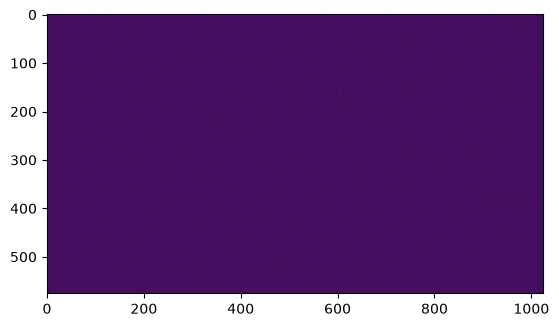

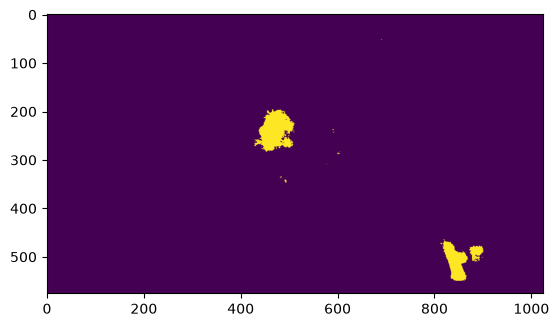

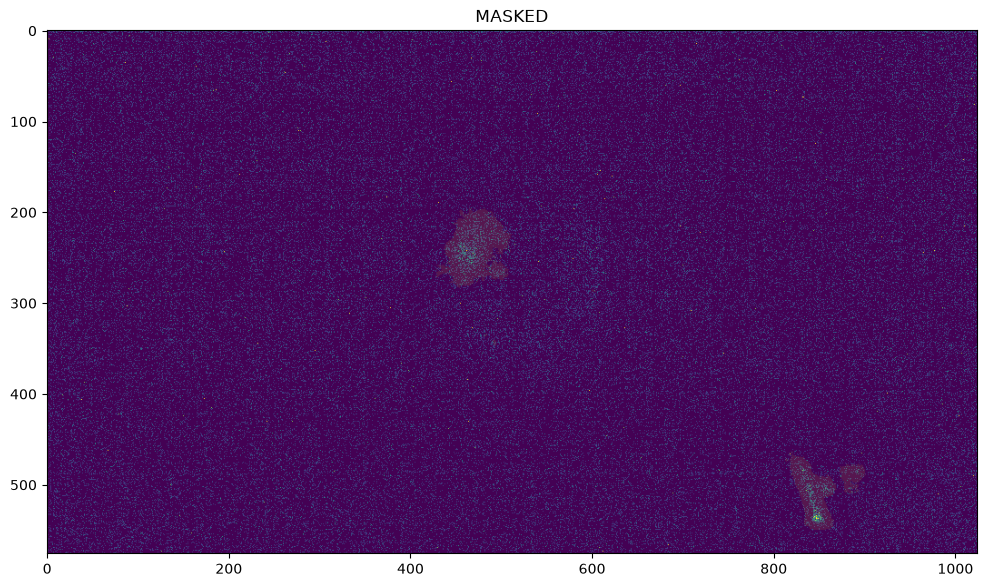

in inference: 12.4 ms per frame


In [73]:
net_file = "2026_Jul_23__16:17_best_model_base16_res_drop.pt"

net_path = os.path.join(net_folder, net_file)
device = "cuda"

net = cygnet.SkipNet(16).to(device)
net.load_state_dict(torch.load(net_path, weights_only=False)['model_state_dict'])
net.eval()

tresh = 0.2

def quickplot(img):
	plt.figure()
	plt.imshow(img.cpu().squeeze())
	plt.show()

def evaluate(pred, mask, threshold=0.2):
	pred_prob = torch.sigmoid(pred)
	pred_mask = pred_prob > threshold
	true_mask = mask > 0.5

	tp = (pred_mask & true_mask).sum().item()
	fp = (pred_mask & ~true_mask).sum().item()
	fn = (~pred_mask & true_mask).sum().item()

	recall    = tp / (tp + fn + 1e-8)
	precision = tp / (tp + fp + 1e-8)
	compression = pred_mask.float().mean().item()
	loss = sigmoid_focal_loss(mask, pred, reduction="mean").item()

	print(f"focal loss : {loss:.4f}")
	print(f"recall     : {recall:.4f}")
	print(f"precision  : {precision:.4f}")
	print(f"compression: {compression:.4%}")

with torch.inference_mode():
	pred = net(in_img.unsqueeze(0).to(device))
spred = torch.sigmoid(pred)
sspred = (spred > tresh).float()

print(pred.max(), pred.min())
print(spred.max(), spred.min())

quickplot(in_img)
quickplot(sspred)

cygnet.debug_plot(d_img.squeeze(), sspred.cpu().squeeze(), 0.1, vmin=200, vmax=205)

#evaluate(pred.cpu().squeeze(), mask.cpu().squeeze())

in_img = in_img.to(device).unsqueeze(0)
net.eval()
# Warmup
for _ in range(10):
    _ = net(in_img)

torch.cuda.synchronize()
t0 = time.perf_counter()
for _ in range(10):
    with torch.inference_mode():
        _ = net(in_img)
torch.cuda.synchronize()
tim = (time.perf_counter() - t0) / 10 * 1000
print(f"in inference: {tim:.1f} ms per frame")
